# Customer Churn Prediction

## Phase 1: Data Understanding

---

### Objective

Before building any machine learning model, it is important to understand the dataset thoroughly.

The objective of this notebook is to understand the business context, dataset structure, target variable, feature categories, and the questions that need to be answered before performing exploratory data analysis (EDA).

# 1. Dataset Overview

The IBM Telco Customer Churn dataset contains information about customers of a telecommunications company.

The dataset includes:

- Customer demographic information
- Account information
- Services subscribed by customers
- Billing details
- Customer churn status

The primary objective is to predict whether a customer is likely to leave the company.

# 2. Business Context

Telecommunication companies invest significant resources in acquiring new customers.

However, acquiring a new customer is usually much more expensive than retaining an existing one.

If businesses can identify customers who are likely to leave, they can proactively offer discounts, improve customer support, or recommend better plans.

Reducing customer churn directly increases customer retention, customer lifetime value, and business revenue.

# 3. Dataset Source

Dataset Name:

IBM Telco Customer Churn Dataset

Source:

IBM Sample Dataset

Domain:

Telecommunications

Number of Records:

7,043 customers

Problem Type:

Binary Classification

# 4. Problem Type

This is a supervised machine learning problem.

More specifically, it is a Binary Classification problem.

The model predicts one of two possible outcomes:

- Churn = Yes
- Churn = No

The objective is to classify each customer into one of these two classes.

# 5. Target Variable

Target Variable:

Churn

Possible Values:

- Yes
- No

The target variable represents whether a customer has left the company.

Every machine learning model in this project will attempt to predict this column.

# 6. Feature Categories

The dataset contains multiple categories of features.

## Customer Information

- gender
- SeniorCitizen
- Partner
- Dependents

## Account Information

- tenure
- Contract
- PaperlessBilling
- PaymentMethod

## Services

- PhoneService
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

## Billing Information

- MonthlyCharges
- TotalCharges

# 7. Initial Questions

Before performing exploratory data analysis, the following questions should be answered.

- Which features are numerical?
- Which features are categorical?
- Are there missing values?
- Is the dataset balanced?
- Which features are most likely related to churn?
- Which columns require preprocessing?
- Are there duplicate records?
- Which columns should not be used for prediction?

# 8. Next Steps

The next notebook will focus on Exploratory Data Analysis (EDA).

The objectives of the next phase are:

- Load the dataset
- Inspect the data
- Understand data types
- Identify missing values
- Explore feature distributions
- Analyze the target variable
- Discover relationships between variables

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [3]:
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
(df["TotalCharges"] == "").sum()

np.int64(0)

In [7]:
type(df["TotalCharges"].iloc[0])

str

In [8]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [15]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

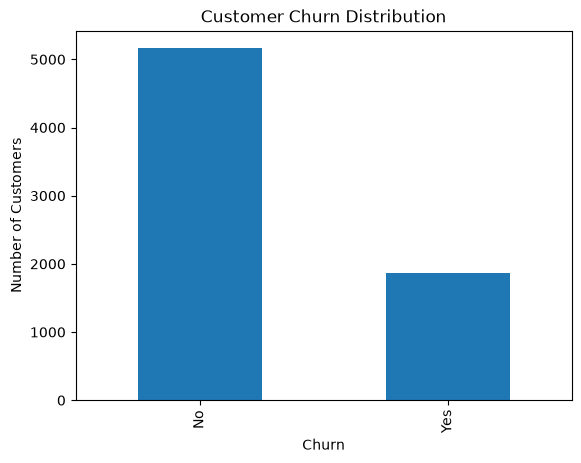

In [17]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Observation

- The dataset contains two classes: Churn = Yes and Churn = No.
- Approximately 73% of customers did not churn.
- Approximately 27% of customers churned.
- The dataset is moderately imbalanced but still suitable for binary classification.

In [18]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

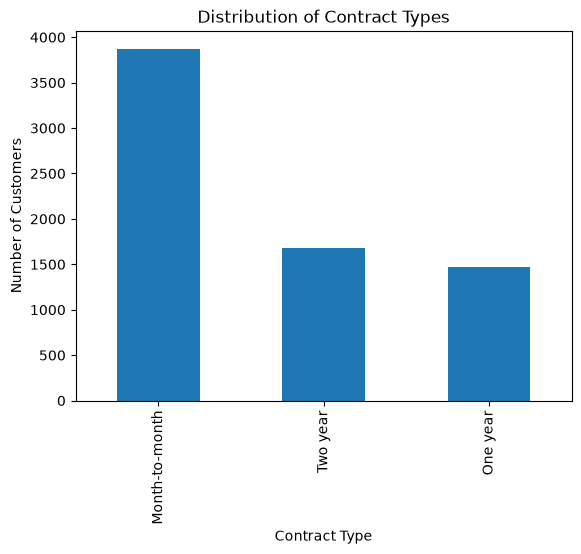

In [19]:
df["Contract"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [21]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## Observation

- Customers on month-to-month contracts have the highest churn rate.
- Customers with one-year and two-year contracts are much less likely to churn.
- Contract type appears to be a strong predictor of customer churn.

In [22]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

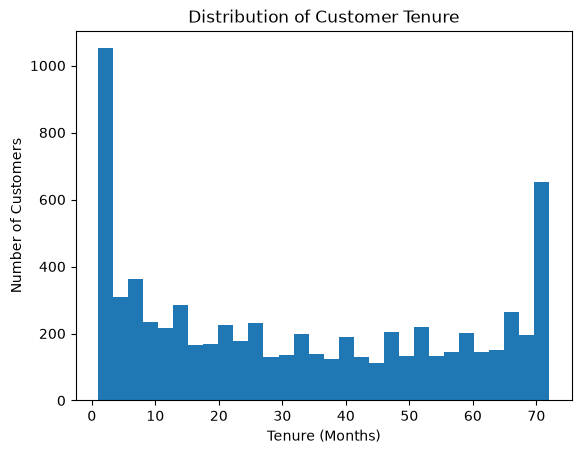

In [23]:
df["tenure"].plot(kind="hist", bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

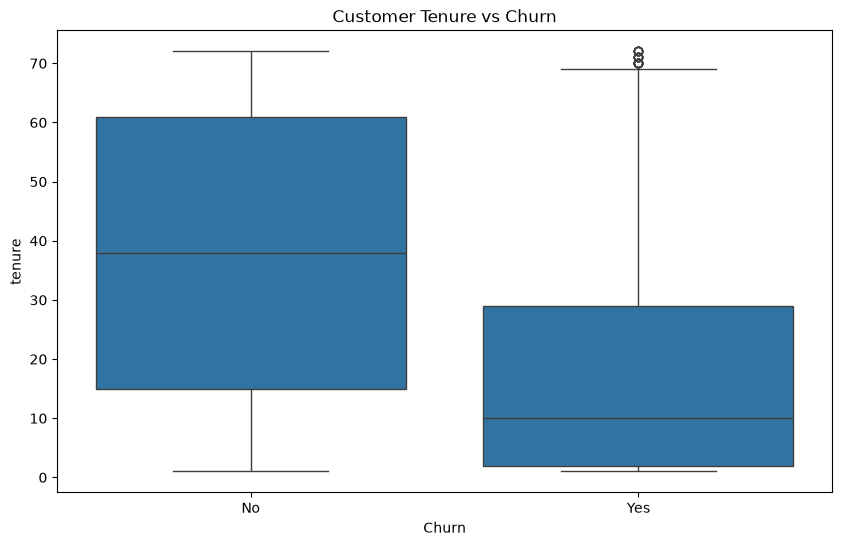

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Customer Tenure vs Churn")

plt.show()

## Observation

- Customers with lower tenure show a higher tendency to churn.
- Long-term customers are significantly more likely to stay.
- Tenure appears to be one of the strongest predictors of customer churn.

In [25]:
df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

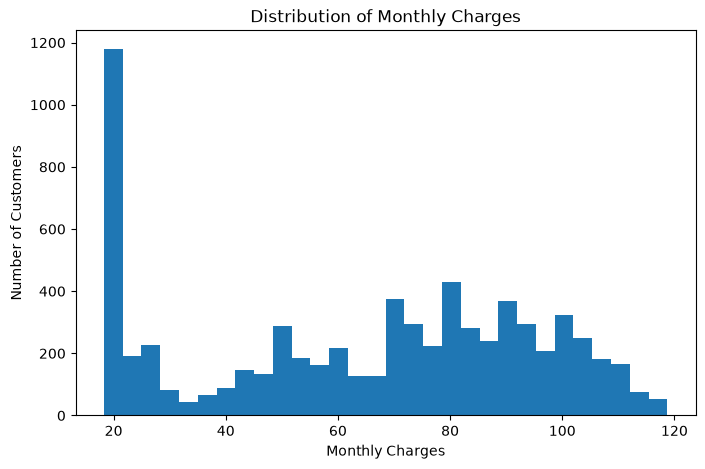

In [26]:
plt.figure(figsize=(8,5))

df["MonthlyCharges"].plot(kind="hist", bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

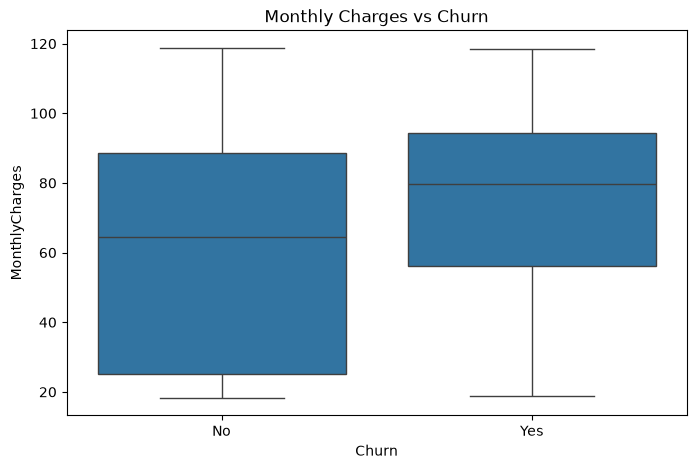

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

## Observation

- Customers who churn tend to have higher monthly charges.
- MonthlyCharges appears to have a positive relationship with churn.
- Pricing strategy may influence customer retention.

In [28]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

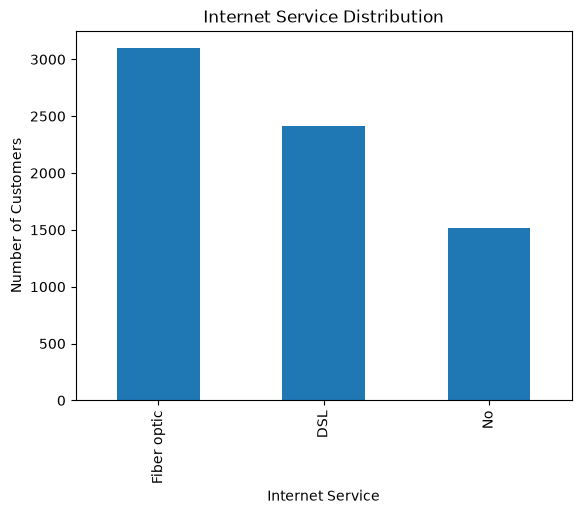

In [29]:
df["InternetService"].value_counts().plot(kind="bar")

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [31]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


## Business Question

Does Internet Service affect customer churn?

## Observation

- Customers using Fiber Optic service have the highest churn rate.
- DSL customers churn less frequently.
- Customers without internet service have the lowest churn rate.

## Business Insight

The company should investigate why Fiber Optic customers leave more often. Possible areas include pricing, network quality, or customer support.

In [32]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


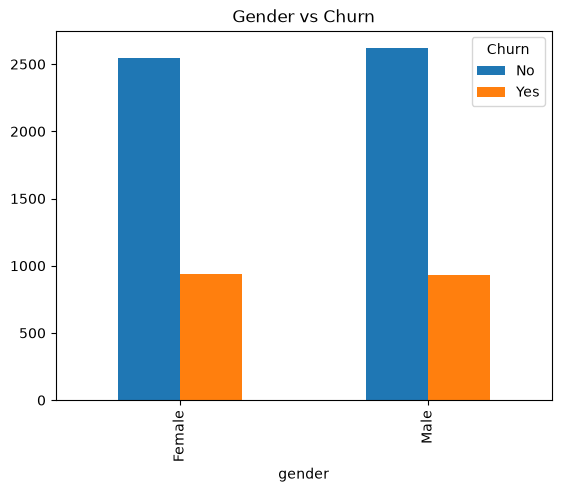

In [33]:
pd.crosstab(
    df["gender"],
    df["Churn"]
).plot(kind="bar")

plt.title("Gender vs Churn")
plt.show()

In [34]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [35]:
pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [36]:
pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


# Demographic Feature Analysis

## Business Question

Do demographic characteristics of customers influence customer churn?

The objective of this analysis is to understand whether customer demographics are associated with customer churn. Identifying such relationships helps the business understand which customer groups are at higher risk and whether demographic information contributes meaningfully to churn prediction.

---

## Features Analyzed

- Gender
- Senior Citizen
- Partner
- Dependents

---

## Summary of Findings

| Feature | Observation | Business Interpretation | Importance |
|----------|-------------|-------------------------|------------|
| Gender | Almost identical churn rate for males and females | Gender does not appear to influence customer churn significantly. | ⭐ |
| SeniorCitizen | Senior citizens exhibit a higher churn rate | Senior customers may require better customer support, personalized plans, or improved service quality. | ⭐⭐⭐ |
| Partner | Customers with partners generally churn less | Customers with partners appear to have greater long-term stability and loyalty. | ⭐⭐⭐ |
| Dependents | Customers with dependents churn less frequently | Customers with dependents may have stronger long-term relationships with the company. | ⭐⭐⭐ |

---

## Key Observations

- Gender has very little relationship with customer churn.
- Senior citizens are more likely to churn than non-senior customers.
- Customers with partners tend to remain with the company longer.
- Customers with dependents generally show lower churn rates.

---

## Business Insight

Among the demographic variables, **SeniorCitizen**, **Partner**, and **Dependents** demonstrate meaningful relationships with customer churn, while **Gender** contributes very little information.

These findings suggest that demographic features alone are insufficient to predict churn accurately. They should be combined with behavioral and service-related features such as **Contract**, **Tenure**, **MonthlyCharges**, and **InternetService**, which are expected to have a stronger influence on customer churn.

In [37]:
service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [38]:
for feature in service_features:

    print("=" * 60)
    print(feature)
    print("=" * 60)

    display(
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    )

PhoneService


Churn,No,Yes
PhoneService,,
No,75.000000,25.000000
Yes,73.252519,26.747481


MultipleLines


Churn,No,Yes
MultipleLines,,
No,74.918759,25.081241
No phone service,75.000000,25.000000
Yes,71.351534,28.648466


InternetService


...

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


StreamingTV


Churn,No,Yes
StreamingTV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


StreamingMovies


Churn,No,Yes
StreamingMovies,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398


# Service Feature Summary

| Feature | Relationship with Churn | Business Interpretation | Importance |
|----------|-------------------------|-------------------------|------------|
| InternetService | Strong | Fiber users churn more | ⭐⭐⭐⭐ |
| OnlineSecurity | Very Strong | Customers without online security churn much more | ⭐⭐⭐⭐⭐ |
| OnlineBackup | Moderate | Customers without backup churn more | ⭐⭐⭐ |
| DeviceProtection | Moderate | Lower churn among subscribers | ⭐⭐⭐ |
| TechSupport | Very Strong | Customers without support churn significantly more | ⭐⭐⭐⭐⭐ |
| StreamingTV | Weak | Small difference | ⭐⭐ |
| StreamingMovies | Weak | Small difference | ⭐⭐ |
| PhoneService | Very Weak | Little effect | ⭐ |
| MultipleLines | Weak | Minor difference | ⭐⭐ |

In [39]:
df["Churn_Binary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [40]:
df[["Churn", "Churn_Binary"]].head()

,Churn,Churn_Binary
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [41]:
df[["tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Binary"]].corr()

,tenure,MonthlyCharges,TotalCharges,Churn_Binary
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn_Binary,-0.354049,0.192858,-0.199484,1.000000


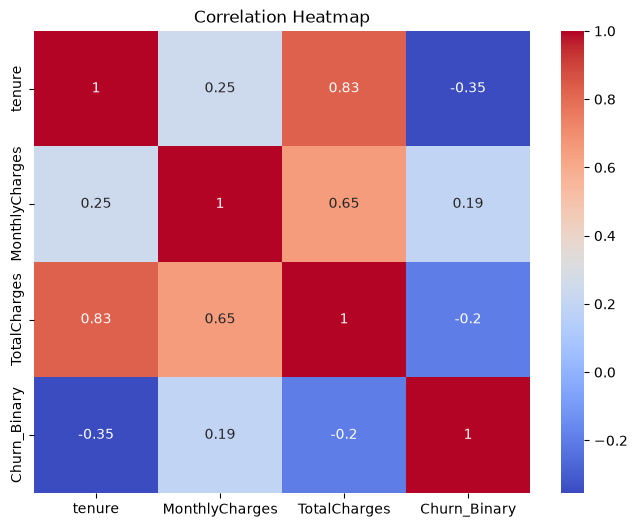

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn_Binary"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Numerical Feature Correlation

## Business Question

Which numerical features show the strongest relationship with customer churn?

---

## Findings

- Tenure shows a negative correlation with churn.
- Monthly Charges show a positive correlation with churn.
- Total Charges show a negative correlation with churn.

---

## Business Insight

Customer tenure is one of the strongest indicators of churn. Customers who remain with the company longer are substantially less likely to leave. Early customer engagement and retention strategies should therefore be prioritized.

In [45]:
df.to_csv("../data/processed/telco_cleaned.csv", index=False)